In [42]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder


In [43]:
conn = sqlite3.connect("data\credit_risk.db")
df= pd.read_sql("SELECT * from credito_integrado",conn)
print(df.dtypes)
print(df.head)

person_age                      int64
person_income                 float64
person_home_ownership             str
person_emp_length              object
loan_intent                       str
loan_grade                        str
loan_amnt                     float64
loan_int_rate                  object
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
date                            int64
year                            int64
month                           int64
unnamed_0                         str
unnamed_1                         str
ipca                          float64
no                            float64
dez_93_100                    float64
no_1                          float64
n12                           float64
ipca_tipo                         str
mes_num                         int64
data_ref                          str
selic_media                   float64
dtype: objec

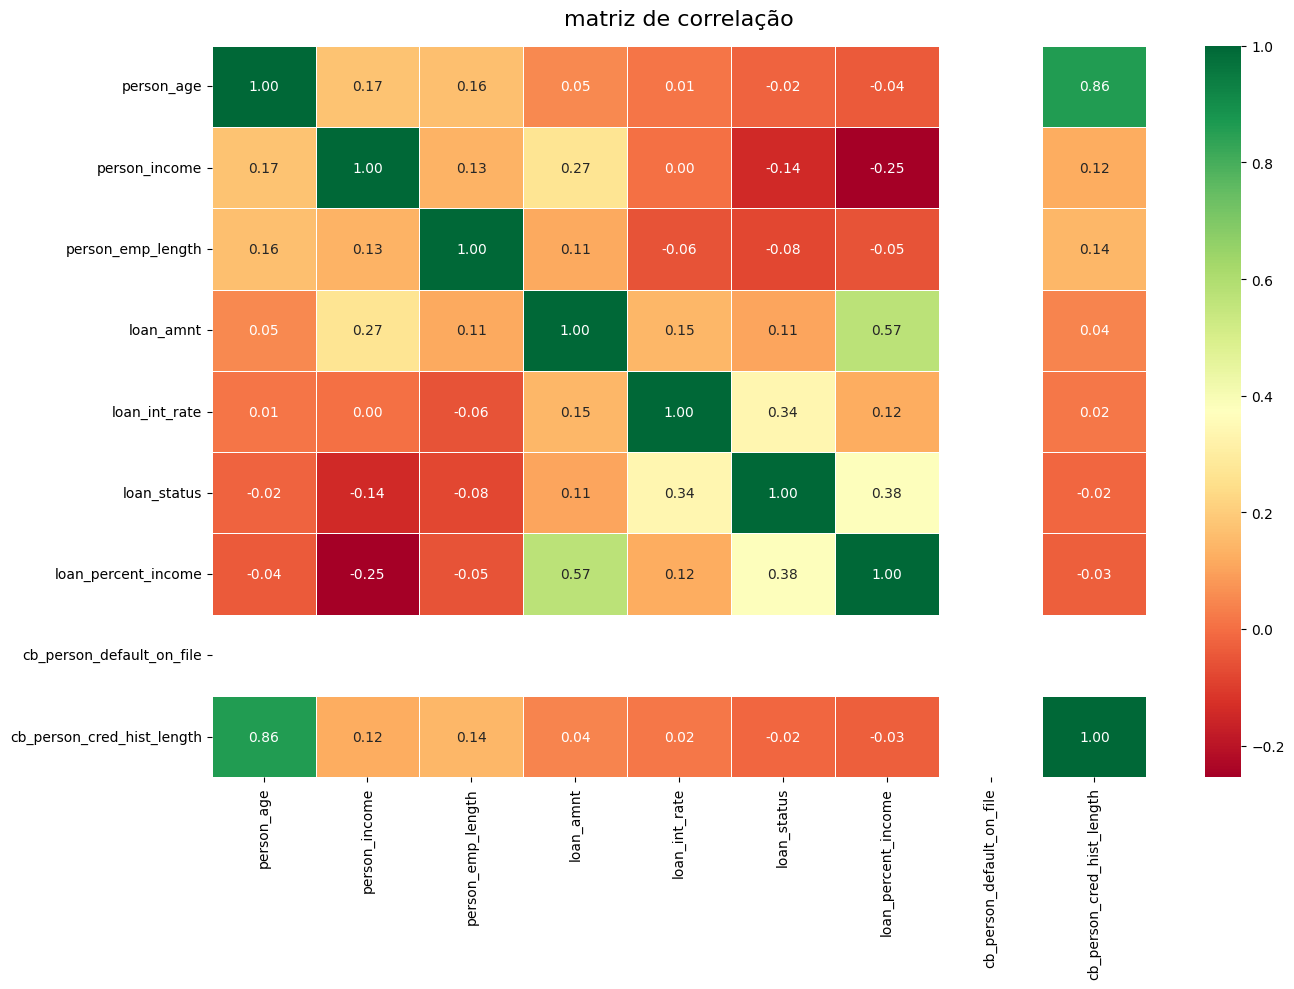

In [ ]:
df['loan_int_rate']= pd.to_numeric(df['loan_int_rate' ],errors='coerce')

cols =[
    'person_age', 'person_income','person_emp_length',
                   'loan_amnt','loan_int_rate', 'loan_status','loan_percent_income',
                   'cb_person_default_on_file','cb_person_cred_hist_length'
] 

df_corr =df[cols].copy()
for col in df_corr:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')


df_corr['person_emp_length'] = pd.to_numeric(df_corr['person_emp_length'], errors='coerce')
corr_matrix = df_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('matriz de correlação', fontsize=16, pad=15)
plt.tight_layout()
plt.show()                   
